# CAB420, Transformers, Additional Example 2: Swin (Shifted-Window) Transformers
Dr Simon Denman (s.denman@qut.edu.au)

## Overview

Transformers are awesome, but they are also slow. In particular, the standard self-attention mechanism (which is where all the power of transformers comes from really) is very demanding. The need to compare every token with every token means that for large representations things get very demanding. For images in particular, this can lead to some tough decisions. Using smaller patches can better capture fine-grained information in local regions (particularly important if we're going to do segmentation or something), but that leads to a huge number of tokens and subsequent pain when running models. 

Swin Transformers propose a solutions to this. In particular:
* Windowed attention is introduced to get away from the quadratic complexity of regular self-attention, such that attention is only computed in local windows.
* Windowed attention will stop information being shared across the whole set of tokens, which is not ideal, so shifted windows are introduced such that successive attention operations will use a different set of windows, allowing information to spread across the tokens.
* Patch merging is introduced to effectively combine patches as the network goes deeper. This works a lot like max pooling does. For an image representation, this has other nice benefits for tasks like segmentation as we can get features at multiple resolutions, to help capture those fine local details that might be critical.

This example won't worry about segmentation and will just focus on our standard classification task, but it will give an idea of how Swin Transformers can be put together. This example is adapted from [here](https://keras.io/examples/vision/swin_transformers/).

### WARNING

**Once again, this example will not be quick to run if you don't have a GPU. Even if you do have a GPU, be careful with some of the parameters around network size - you may make things run very, very slowly.**

## Too Long; Didn't Read:
The main take home messages from this example are:
* The standard self-attention operation used in transformers in very powerful, but also very resource intensive and very slow.
* Swin Transformers propose using a shifted window attention. This creates a set of local windows in which attention is computed, and shifts these windows in successive layers such that information can propogate around the tokens.
* To further help capture more global information, patches are merged as the network gets deeper, similar to what we've done with max pooling in CNNs.
* Overall, Swin Transformers don't lead to a huge gain in performance (if there is any gain at all), but they can achieve comparable performance with greatly reduced resources. 

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf

import keras
from keras import layers
from keras import ops

import matplotlib.pyplot as plt
import numpy as np

E0000 00:00:1768879997.406818  182933 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768879997.410769  182933 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768879997.421452  182933 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768879997.421468  182933 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768879997.421470  182933 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768879997.421473  182933 computation_placer.cc:177] computation placer already registered. Please check linka

## Parameters

Again, we have a bunch of options. These are mostly the defaults from the keras example, though I've dropped the embedding dimension and MLP size to be consistent with what we've used in other examples. 

One difference in our configuration here is that we are starting with very small (2 x 2) patches. This might seem like something that will cripple computers by creating a huge number of tokens, but becuase we're only going to compute attention in local windows, things won't explode. 

If you want to tweak settings here, the number of heads, embedding dimension, and MLP dimension are obvious ones to play with.

In [2]:
num_classes = 100
input_shape = (32, 32, 3)

patch_size = (2, 2)  # 2-by-2 sized patches
dropout_rate = 0.03  # Dropout rate
num_heads = 4  # Attention heads
embed_dim = 32  # Embedding dimension
num_mlp = 64  # MLP layer size

# Convert embedded patches to query, key, and values with a learnable additive
# value
qkv_bias = True
window_size = 2  # Size of attention window
shift_size = 1  # Size of shifting window
image_dimension = 32  # Initial image size

# compute number of patches
num_patch_x = input_shape[0] // patch_size[0]
num_patch_y = input_shape[1] // patch_size[1]

# training parameters
learning_rate = 1e-3
batch_size = 128
num_epochs = 40
weight_decay = 0.0001
label_smoothing = 0.1

## The Data

We're going to use CIFAR-100 here, same as before.

In [3]:
num_classes = 100
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_val = x_train[45000:, :]
y_val = y_train[45000:]
x_train = x_train[0:45000, :]
y_train = y_train[0:45000]

## Network Functions

Swin Transformer is all about apply attention over local windows. This scales far better than the global attention used in regular transformers, so makes the models much more efficient.

### Window Functions and Window Attention

We have a couple of helper functions here to deal with the windows that we compute attention over. These will:
* split an image representation into a set of patches
* reform a set of patches into an image representation

These functions will be used in the SwinTransformer class below to get the data into and out of the window shapes we need for the window attention. We also have the window attention layer itself defined here.

In [4]:
def window_partition(x, window_size):
    _, height, width, channels = x.shape
    patch_num_y = height // window_size
    patch_num_x = width // window_size
    x = ops.reshape(x, (-1, patch_num_y, window_size, patch_num_x, window_size, channels))
    x = ops.transpose(x, (0, 1, 3, 2, 4, 5))
    windows = ops.reshape(x, (-1, window_size, window_size, channels))
    return windows


def window_reverse(windows, window_size, height, width, channels):
    patch_num_y = height // window_size
    patch_num_x = width // window_size
    x = ops.reshape(windows, ( -1, patch_num_y, patch_num_x, window_size, window_size, channels))
    x = ops.transpose(x, (0, 1, 3, 2, 4, 5))
    x = ops.reshape(x, (-1, height, width, channels))
    return x
    
class WindowAttention(layers.Layer):
    def __init__(
        self,
        dim,
        window_size,
        num_heads,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.dropout = layers.Dropout(dropout_rate)
        self.proj = layers.Dense(dim)

        num_window_elements = (2 * self.window_size[0] - 1) * (2 * self.window_size[1] - 1)
        self.relative_position_bias_table = self.add_weight(shape=(num_window_elements, self.num_heads),
                                                            initializer=keras.initializers.Zeros(), trainable=True)
        coords_h = np.arange(self.window_size[0])
        coords_w = np.arange(self.window_size[1])
        coords_matrix = np.meshgrid(coords_h, coords_w, indexing="ij")
        coords = np.stack(coords_matrix)
        coords_flatten = coords.reshape(2, -1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.transpose([1, 2, 0])
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)

        self.relative_position_index = keras.Variable(initializer=relative_position_index, shape=relative_position_index.shape, 
                                                      dtype="int", trainable=False)

    def call(self, x, mask=None):
        _, size, channels = x.shape
        head_dim = channels // self.num_heads
        x_qkv = self.qkv(x)
        x_qkv = ops.reshape(x_qkv, (-1, size, 3, self.num_heads, head_dim))
        x_qkv = ops.transpose(x_qkv, (2, 0, 3, 1, 4))
        q, k, v = x_qkv[0], x_qkv[1], x_qkv[2]
        q = q * self.scale
        k = ops.transpose(k, (0, 1, 3, 2))
        attn = q @ k

        num_window_elements = self.window_size[0] * self.window_size[1]
        relative_position_index_flat = ops.reshape(self.relative_position_index, (-1,))
        relative_position_bias = ops.take(self.relative_position_bias_table, relative_position_index_flat, axis=0)
        relative_position_bias = ops.reshape(relative_position_bias, (num_window_elements, num_window_elements, -1))
        relative_position_bias = ops.transpose(relative_position_bias, (2, 0, 1))
        attn = attn + ops.expand_dims(relative_position_bias, axis=0)

        if mask is not None:
            nW = mask.shape[0]
            mask_float = ops.cast(ops.expand_dims(ops.expand_dims(mask, axis=1), axis=0), "float32")
            attn = ops.reshape(attn, (-1, nW, self.num_heads, size, size)) + mask_float
            attn = ops.reshape(attn, (-1, self.num_heads, size, size))
            attn = keras.activations.softmax(attn, axis=-1)
        else:
            attn = keras.activations.softmax(attn, axis=-1)
        attn = self.dropout(attn)

        x_qkv = attn @ v
        x_qkv = ops.transpose(x_qkv, (0, 2, 1, 3))
        x_qkv = ops.reshape(x_qkv, (-1, size, channels))
        x_qkv = self.proj(x_qkv)
        x_qkv = self.dropout(x_qkv)
        return x_qkv

### Swin Transformer Class

Next up we have the swin transformer class. This is really fairly similar to our regular transformer class, we're just replacing the standard multi-head self attention, which computes global self attention (i.e. attention between all tokens) and is thus very slow, with the windowed self attention created above.

In [5]:
class SwinTransformer(layers.Layer):
    def __init__(
        self,
        dim,
        num_patch,
        num_heads,
        window_size=7,
        shift_size=0,
        num_mlp=1024,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.dim = dim  # number of input dimensions
        self.num_patch = num_patch  # number of embedded patches
        self.num_heads = num_heads  # number of attention heads
        self.window_size = window_size  # size of window
        self.shift_size = shift_size  # size of window shift
        self.num_mlp = num_mlp  # number of MLP nodes

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(
            dim,
            window_size=(self.window_size, self.window_size),
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            dropout_rate=dropout_rate,
        )
        self.drop_path = layers.Dropout(dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)

        self.mlp = keras.Sequential(
            [
                layers.Dense(num_mlp),
                layers.Activation(keras.activations.gelu),
                layers.Dropout(dropout_rate),
                layers.Dense(dim),
                layers.Dropout(dropout_rate),
            ]
        )

        if min(self.num_patch) < self.window_size:
            self.shift_size = 0
            self.window_size = min(self.num_patch)

    def build(self, input_shape):
        if self.shift_size == 0:
            self.attn_mask = None
        else:
            height, width = self.num_patch
            h_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            w_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            mask_array = np.zeros((1, height, width, 1))
            count = 0
            for h in h_slices:
                for w in w_slices:
                    mask_array[:, h, w, :] = count
                    count += 1
            mask_array = ops.convert_to_tensor(mask_array)

            # mask array to windows
            mask_windows = window_partition(mask_array, self.window_size)
            mask_windows = ops.reshape(
                mask_windows, [-1, self.window_size * self.window_size]
            )
            attn_mask = ops.expand_dims(mask_windows, axis=1) - ops.expand_dims(
                mask_windows, axis=2
            )
            attn_mask = ops.where(attn_mask != 0, -100.0, attn_mask)
            attn_mask = ops.where(attn_mask == 0, 0.0, attn_mask)
            self.attn_mask = keras.Variable(
                initializer=attn_mask,
                shape=attn_mask.shape,
                dtype=attn_mask.dtype,
                trainable=False,
            )

    def call(self, x, training=False):
        height, width = self.num_patch
        _, num_patches_before, channels = x.shape
        x_skip = x
        x = self.norm1(x)
        x = ops.reshape(x, (-1, height, width, channels))
        if self.shift_size > 0:
            shifted_x = ops.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])
        else:
            shifted_x = x

        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = ops.reshape(x_windows, (-1, self.window_size * self.window_size, channels))
        attn_windows = self.attn(x_windows, mask=self.attn_mask)

        attn_windows = ops.reshape(attn_windows, (-1, self.window_size, self.window_size, channels))
        shifted_x = window_reverse(attn_windows, self.window_size, height, width, channels)
        if self.shift_size > 0:
            x = ops.roll(shifted_x, shift=[self.shift_size, self.shift_size], axis=[1, 2])
        else:
            x = shifted_x

        x = ops.reshape(x, (-1, height * width, channels))
        x = self.drop_path(x, training=training)
        x = x_skip + x
        x_skip = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = self.drop_path(x)
        x = x_skip + x
        return x

### Patch Extraction, Embedding and Merging

We have some more utility functions and layers now to help put this all together:
* `patch_extract` is just extracting patches from the image. This is nothing fancy, and really we've seen this before
* `PatchEmbedding` is getting an embedding for a patch, again, we've seen this before.
* `PatchMerging` is a new thing. The Swin Transformer will merge patches between groups of layers, giving us that heirachical structure we see in CNNs. This layer will give us this functionality.

In [6]:
# Using tf ops since it is only used in tf.data.
def patch_extract(images):
    batch_size = tf.shape(images)[0]
    patches = tf.image.extract_patches(
        images=images,
        sizes=(1, patch_size[0], patch_size[1], 1),
        strides=(1, patch_size[0], patch_size[1], 1),
        rates=(1, 1, 1, 1),
        padding="VALID",
    )
    patch_dim = patches.shape[-1]
    patch_num = patches.shape[1]
    return tf.reshape(patches, (batch_size, patch_num * patch_num, patch_dim))


class PatchEmbedding(layers.Layer):
    def __init__(self, num_patch, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patch = num_patch
        self.proj = layers.Dense(embed_dim)
        self.pos_embed = layers.Embedding(input_dim=num_patch, output_dim=embed_dim)

    def call(self, patch):
        pos = ops.arange(start=0, stop=self.num_patch)
        return self.proj(patch) + self.pos_embed(pos)


class PatchMerging(keras.layers.Layer):
    def __init__(self, num_patch, embed_dim):
        super().__init__()
        self.num_patch = num_patch
        self.embed_dim = embed_dim
        self.linear_trans = layers.Dense(2 * embed_dim, use_bias=False)

    def call(self, x):
        height, width = self.num_patch
        _, _, C = x.shape
        x = ops.reshape(x, (-1, height, width, C))
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = ops.concatenate((x0, x1, x2, x3), axis=-1)
        x = ops.reshape(x, (-1, (height // 2) * (width // 2), 4 * C))
        return self.linear_trans(x)

### Augmentation, and Data Preperation

Finally, we have some simple augmentation, and data preperation. This example really is just following the [official keras one](https://keras.io/examples/vision/swin_transformers/), and here we're doing something that perhaps seems a little bit out of step with what we've done in the other VIT examples. Rather than break the image into patches in the network, we're doing it in the data loader. This really doesn't make any difference - we're just moving some fixed operations from the network to the data loader - it does mean that our network will recieve as input a sequences of patches rather than an image. 

In [7]:
def augment(x):
    x = tf.image.random_crop(x, size=(image_dimension, image_dimension, 3))
    x = tf.image.random_flip_left_right(x)
    return x

dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .map(lambda x, y: (augment(x), y))
    .batch(batch_size=batch_size)
    .map(lambda x, y: (patch_extract(x), y))
    .prefetch(tf.data.experimental.AUTOTUNE)
)

dataset_val = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(batch_size=batch_size)
    .map(lambda x, y: (patch_extract(x), y))
    .prefetch(tf.data.experimental.AUTOTUNE)
)

dataset_test = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(batch_size=batch_size)
    .map(lambda x, y: (patch_extract(x), y))
    .prefetch(tf.data.experimental.AUTOTUNE)
)

I0000 00:00:1768880002.656181  182933 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:02:00.0, compute capability: 8.6


## The Network

Finally we get to the network. Some thing to note here:
* As flagged above, our input as a sequence of flattened patches, not an image. The size of 12 for these comes from each patch being $2 \times 2$ RGB pixels (i.e. 12 values)
* We have two groups of `SwinTransformer` layers. The second one of these has the shift applied, to give us our shifted windows and propogate information through the representation
* After each group, we have a `PatchMerging` layer, that will effectivley shrink the size of the representation spatially
* Finally, we have the usual `GlobalAveragePooling1D` to aggregrate features, which we then use to make our final decision

Note too that I've setup the size of the `SwinTransformer` layers to increase as the network gets deeper, like what we did with CNNs. Essentially, we're doubling the size of the embeddings as we go deeper. If I wanted, I could also have another pair of transformer layer and another patch merging here, to add further depth.

In [8]:
input = layers.Input(shape=(256, 12))
x = PatchEmbedding(num_patch_x * num_patch_y, embed_dim)(input)
x = SwinTransformer(dim=embed_dim, num_patch=(num_patch_x, num_patch_y), num_heads=num_heads, window_size=window_size,
                    shift_size=0, num_mlp=num_mlp, qkv_bias=qkv_bias, dropout_rate=dropout_rate)(x)
x = SwinTransformer(dim=embed_dim, num_patch=(num_patch_x, num_patch_y), num_heads=num_heads, window_size=window_size, shift_size=shift_size,
                    num_mlp=num_mlp, qkv_bias=qkv_bias,dropout_rate=dropout_rate)(x)

x = PatchMerging((num_patch_x, num_patch_y), embed_dim=embed_dim)(x)

x = SwinTransformer(dim=embed_dim*2, num_patch=(num_patch_x // 2, num_patch_y // 2),num_heads=num_heads, window_size=window_size,
                    shift_size=0, num_mlp=num_mlp*2, qkv_bias=qkv_bias, dropout_rate=dropout_rate)(x)
x = SwinTransformer(dim=embed_dim*2, num_patch=(num_patch_x // 2, num_patch_y // 2), num_heads=num_heads, window_size=window_size,
                    shift_size=shift_size, num_mlp=num_mlp*2, qkv_bias=qkv_bias, dropout_rate=dropout_rate)(x)

x = PatchMerging((num_patch_x // 2, num_patch_y // 2), embed_dim=embed_dim*2)(x)

x = layers.GlobalAveragePooling1D()(x)
output = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(input, output)

model.summary()

/opt/conda/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'window_attention_1' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'window_attention_3' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 256, 32)        │         8,608 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer                │ (None, 256, 32)        │         8,596 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer_1              │ (None, 256, 32)        │         9,620 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_merging (PatchMerging)    │ (None, 64, 64)         │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer_2              │ (None, 64, 64)         │        33,524 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer_3              │ (None, 64, 64)         │        33,780 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_merging_1 (PatchMerging)  │ (None, 16, 128)        │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,988 (583.33 KB)

 Trainable params: 146,644 (572.83 KB)

 Non-trainable params: 1,344 (10.50 KB)

Overall, our model is surprisingly compact. Looking at the shapes, you can see that we start with 256 patches, which we merge down to 64, and then finally 16. As we merge patches, you can see that the size of the embedding doubles, starting at 32, then increasing to 64, and finally landing at 128.

We'll now train our model. Here we'll use label smoothing and AdamW again.

In [9]:
model.compile(loss=keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
              optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy"), keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy")])

history = model.fit(dataset, batch_size=batch_size, epochs=num_epochs, validation_data=dataset_val, verbose=False)

I0000 00:00:1768880010.845593  182974 service.cc:152] XLA service 0x7f2fcc013ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768880010.845625  182974 service.cc:160]   StreamExecutor device (0): NVIDIA A16-4Q, Compute Capability 8.6
I0000 00:00:1768880012.000052  182974 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768880034.195986  182974 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


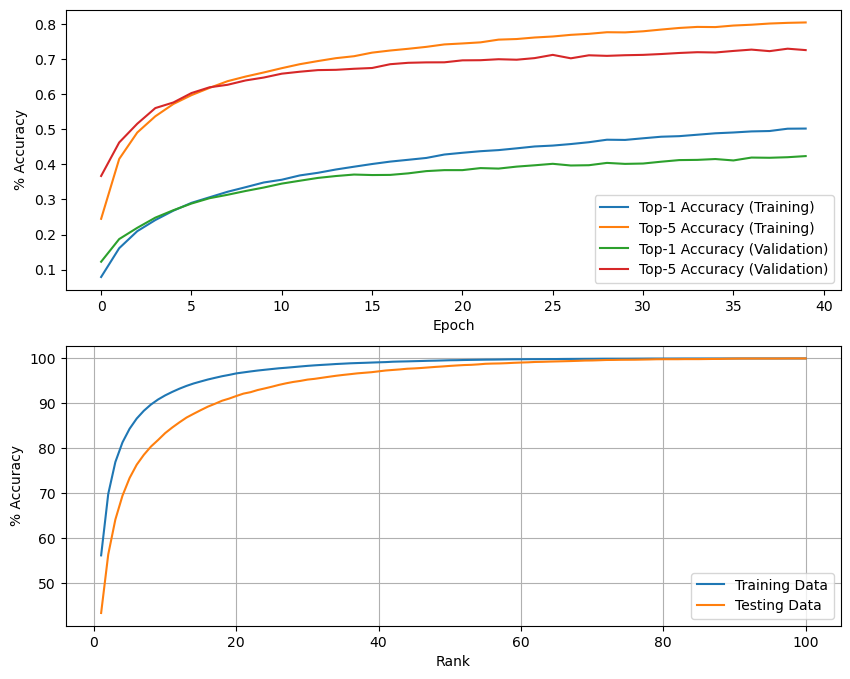

In [10]:
def eval_model(history, model):

    train_predictions = model.predict(dataset, verbose=False)
    test_predictions = model.predict(dataset_test, verbose=False)
    train_samples = len(x_train)
    test_samples = len(x_test)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(2, 1, 1)
    plt.plot(history.history["accuracy"], label="Top-1 Accuracy (Training)")
    plt.plot(history.history["top-5-accuracy"], label="Top-5 Accuracy (Training)")
    plt.plot(history.history["val_accuracy"], label="Top-1 Accuracy (Validation)")
    plt.plot(history.history["val_top-5-accuracy"], label="Top-5 Accuracy (Validation)")
    plt.xlabel('Epoch')
    plt.ylabel('% Accuracy')
    plt.legend()
    
    cmc_train = []
    cmc_test = []
    rank = []
    for i in range(1,101):
        cmc_train.append(100.0*np.sum(tf.math.in_top_k(tf.argmax(y_train, axis=1), train_predictions, i))/train_samples)
        cmc_test.append(100.0*np.sum(tf.math.in_top_k(tf.argmax(y_test, axis=1), test_predictions, i))/test_samples)
        rank.append(i)

    ax = fig.add_subplot(2, 1, 2)
    plt.plot(rank, cmc_train, label="Training Data")
    plt.plot(rank, cmc_test, label="Testing Data")
    plt.grid()
    plt.legend()
    plt.xlabel('Rank')
    plt.ylabel('% Accuracy')

eval_model(history, model)    

Performance wise, our model is pretty good. We see improved performance over our standard VIT, but using convolutional tokens in the VIT was a bit better than what we have here. This is expected, the convolutional tokens do give us a much richer set of featuers to use. We could similarly use convolutional features here to give us a further boost, and we could go deeper too. One thing to note is that we've got four SwinTransformer layers here, whereas with our VITs we've had just two. This may seem like cheating (and is certainly not hurting us performance wise), but the design of the shifted-window attention means that we need those pairs of layers, as we shift the windows to help information propogate across the tokens. 

One thing to note is that if you've run this yourself, you've probably noticed that it ran much faster, even though we've got more attention operations. The windowed attention makes a huge difference in run-times, and is way more efficient than the standard self-attention we've looked at before.

## Final Thoughts

In this example we've had a look at the Swin Transformer. This replaces the standard, and very computationally demanding, self-attention operation, and can help us get good performance much faster. One thing to keep in mind though is that the reason we're looking to replace the standard multi-head attention is not due to an problems with it's ability to represent things well, or acheive good accuracy - it can do that - it's all down to it's efficiency. The windows attention operation here is not about making things more accurate, it's about maintaining the accuracy while making things much more efficient.

If you're thinking that this method is very specific to images, yes it somewhat is, but the idea of windowed attentioned has been applied to other signal data types (audio, videos, point clouds, etc.) with success. There are also tonnes of other alternative attention mechanisms out there that have been proposed with the same aim as the Swin Transformer - achieving performance comparable to self-attention without the computational cost.